# Part III: Hate Speech and Offensive Language Classification using RNN, LSTM and Pretrained Embeddings

This notebook implements an end-to-end NLP text classification pipeline for hate speech detection. It includes dataset understanding, text preprocessing, tokenisation, percentile-based sequence padding, three recurrent neural network models, model comparison, error analysis, and a simple real-time prediction interface.

**Models implemented:**

1. Simple RNN with a trainable embedding layer  
2. LSTM with a trainable embedding layer  
3. LSTM with pretrained GloVe embeddings  

**Important:** Run this notebook from top to bottom in Google Colab. Upload the hate speech dataset ZIP/CSV when prompted, or place the dataset ZIP in `/content/`.

## 1. Install Required Libraries

Only essential libraries are installed. The notebook avoids uninstalling TensorFlow/Keras because that can make the environment unstable.

In [25]:
!pip -q install contractions wordcloud gensim gradio

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Import Libraries and Set Reproducibility

A fixed random seed is used so that the train-test split and model initialisation are more reproducible.

In [27]:
import os
import re
import time
import html
import zipfile
import random
import pickle
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 3. Mount Google Drive and Load the Extracted Dataset

This cell is designed to be robust. It mounts Google Drive and uses the path you paste for the already-extracted dataset folder or CSV file.

Expected dataset format: a CSV file containing a text/tweet column and a label/class column.

In [28]:
from google.colab import drive
from pathlib import Path
import pandas as pd

# Mount Google Drive.
drive.mount("/content/drive")

# ============================================================
# IMPORTANT:
# Paste the path of your already-extracted dataset CSV file OR
# the folder that contains the CSV file.
#
# Example 1: Direct CSV path
# DATASET_PATH = Path("/content/drive/MyDrive/AI Assessment/4. Hate Speech Detection Dataset/labeled_data.csv")
#
# Example 2: Extracted folder path
# DATASET_PATH = Path("/content/drive/MyDrive/AI Assessment/4. Hate Speech Detection Dataset")
# ============================================================

DATASET_PATH = Path("/content/drive/MyDrive/AI & Machine learning /coursework/4. Hate Speech Detection Dataset-20260509T184202Z-3-001")

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset path not found: {DATASET_PATH}\n"
        "Please mount Google Drive and paste the correct extracted folder or CSV file path."
    )

# If the path is a folder, automatically find the CSV file inside it.
if DATASET_PATH.is_dir():
    csv_files = sorted(DATASET_PATH.rglob("*.csv"))

    if len(csv_files) == 0:
        raise FileNotFoundError(
            f"No CSV file found inside folder: {DATASET_PATH}\n"
            "Please check that the dataset is already extracted and contains a CSV file."
        )

    if len(csv_files) > 1:
        print("Multiple CSV files found. Using the first one:")
        for i, file in enumerate(csv_files):
            print(f"{i}: {file}")

    csv_path = csv_files[0]

# If the path is already a CSV file, use it directly.
elif DATASET_PATH.is_file() and DATASET_PATH.suffix.lower() == ".csv":
    csv_path = DATASET_PATH

else:
    raise ValueError(
        "DATASET_PATH must be either an extracted dataset folder or a .csv file."
    )

print("Dataset CSV path:", csv_path)

df_raw = pd.read_csv(csv_path, encoding="utf-8", on_bad_lines="skip")
print("Original dataset shape:", df_raw.shape)
display(df_raw.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset CSV path: /content/drive/MyDrive/AI & Machine learning /coursework/4. Hate Speech Detection Dataset-20260509T184202Z-3-001/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv
Original dataset shape: (24783, 2)


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


## 4. Standardise Columns, Fix Labels and Remove Duplicates

The original dataset may contain a spelling issue such as `hate speec`. This is corrected to `hate speech` to make the notebook professional and consistent.

In [29]:
df = df_raw.copy()

lower_cols = {col.lower().strip(): col for col in df.columns}

text_candidates = ["text", "tweet", "content", "comment", "sentence"]
label_candidates = ["label", "class", "category", "target"]

TEXT_COL = None
LABEL_COL = None

for col in text_candidates:
    if col in lower_cols:
        TEXT_COL = lower_cols[col]
        break

for col in label_candidates:
    if col in lower_cols:
        LABEL_COL = lower_cols[col]
        break

# Fallback: choose likely text column by longest average string length.
if TEXT_COL is None:
    object_cols = df.select_dtypes(include=["object"]).columns.tolist()
    if len(object_cols) == 0:
        raise ValueError("No text-like column found in the dataset.")
    TEXT_COL = max(object_cols, key=lambda c: df[c].astype(str).str.len().mean())

# Fallback: choose likely label column by low unique count.
if LABEL_COL is None:
    possible_label_cols = [
        col for col in df.columns
        if col != TEXT_COL and df[col].nunique() <= 20
    ]
    if len(possible_label_cols) == 0:
        raise ValueError("Could not detect label column.")
    LABEL_COL = possible_label_cols[0]

df = df[[TEXT_COL, LABEL_COL]].rename(columns={TEXT_COL: "text", LABEL_COL: "label"})

df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(str).str.strip().str.lower()

df["label"] = df["label"].replace({
    "hate speec": "hate speech",
    "hate_speech": "hate speech",
    "hate-speech": "hate speech",
    "offensive_language": "offensive language",
    "offensive-language": "offensive language",
    "offensive": "offensive language"
})

df = df[df["text"].str.strip().ne("")]
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts())
display(df.head())

Cleaned dataset shape: (24783, 2)

Class distribution:
label
offensive language    19190
neither                4163
hate speech            1430
Name: count, dtype: int64


,text,label
0,!!! RT @mayasolovely: As a woman you shouldn't...,neither
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,offensive language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,offensive language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,offensive language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,offensive language


## 5. Dataset Understanding and Visualisation

This section answers the dataset-understanding requirement by showing the number of text instances, number of classes, class distribution, and basic text length patterns.

Dataset overview
----------------
Total text instances: 24783
Number of classes: 3
Classes: ['neither', 'offensive language', 'hate speech']

Class distribution:
label
offensive language    19190
neither                4163
hate speech            1430
Name: count, dtype: int64

Imbalance ratio: 13.42:1


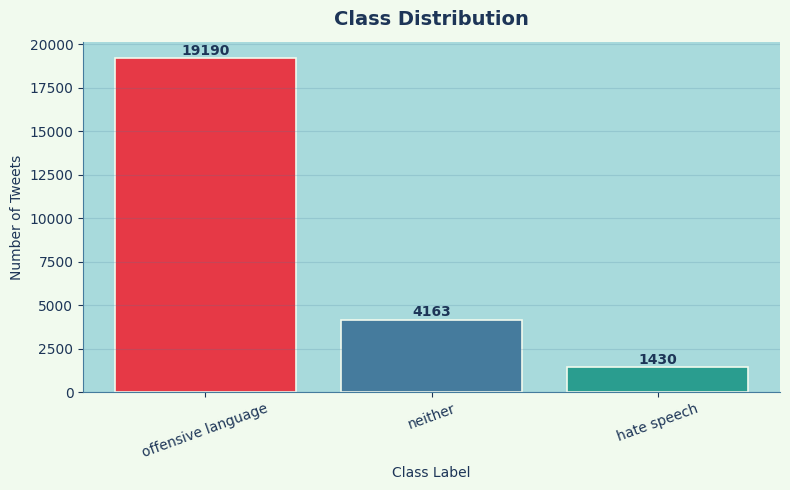

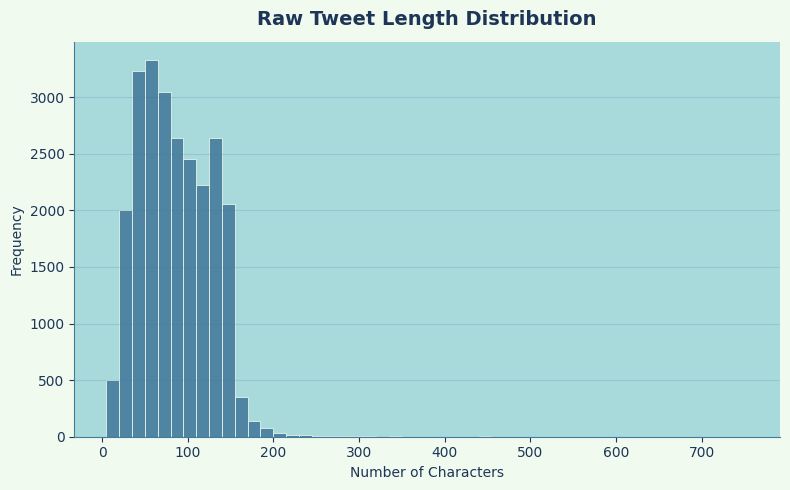


Sample records:


,text,label,raw_text_length
2281,934 8616\ni got a missed call from yo bitch,offensive language,42
15914,RT @KINGTUNCHI_: Fucking with a bad bitch you ...,offensive language,77
18943,RT @eanahS__: @1inkkofrosess lol my credit ain...,neither,130
16407,RT @Maxin_Betha Wipe the cum out of them faggo...,offensive language,102
13326,Niggas cheat on they bitch and don't expect no...,offensive language,104


In [30]:
print("Dataset overview")
print("----------------")
print("Total text instances:", len(df))
print("Number of classes:", df["label"].nunique())
print("Classes:", df["label"].unique().tolist())
counts = df["label"].value_counts()
imbalance_ratio = counts.max() / counts.min()
print("\nClass distribution:")
print(counts)
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")

# ── Color palette
BAR_COLORS  = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261']
HIST_COLOR  = '#457B9D'
EDGE_COLOR  = '#F1FAEE'
BG_COLOR    = '#F1FAEE'
AXES_COLOR  = '#A8DADC'
TEXT_COLOR  = '#1D3557'
GRID_COLOR  = '#457B9D'

# ── Bar chart — Class Distribution
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(AXES_COLOR)
bars = ax.bar(
    counts.index, counts.values,
    color=BAR_COLORS[:len(counts)],
    edgecolor=EDGE_COLOR,
    linewidth=1.2
)
ax.set_title("Class Distribution", fontsize=14, fontweight='bold', color=TEXT_COLOR, pad=12)
ax.set_xlabel("Class Label", color=TEXT_COLOR)
ax.set_ylabel("Number of Tweets", color=TEXT_COLOR)
ax.tick_params(axis='x', rotation=20, colors=TEXT_COLOR)
ax.tick_params(axis='y', colors=TEXT_COLOR)
ax.grid(axis='y', alpha=0.2, color=GRID_COLOR)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(GRID_COLOR)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 20,
        str(int(height)),
        ha="center",
        va="bottom",
        color=TEXT_COLOR,
        fontweight='bold',
        fontsize=10
    )
plt.tight_layout()
plt.show()

# ── Histogram — Raw Tweet Length Distribution
df["raw_text_length"] = df["text"].str.len()
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(AXES_COLOR)
ax.hist(
    df["raw_text_length"],
    bins=50,
    color=HIST_COLOR,
    edgecolor=EDGE_COLOR,
    linewidth=0.6,
    alpha=0.9
)
ax.set_title("Raw Tweet Length Distribution", fontsize=14, fontweight='bold', color=TEXT_COLOR, pad=12)
ax.set_xlabel("Number of Characters", color=TEXT_COLOR)
ax.set_ylabel("Frequency", color=TEXT_COLOR)
ax.tick_params(axis='x', colors=TEXT_COLOR)
ax.tick_params(axis='y', colors=TEXT_COLOR)
ax.grid(axis='y', alpha=0.2, color=GRID_COLOR)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(GRID_COLOR)
plt.tight_layout()
plt.show()

print("\nSample records:")
display(df.sample(5, random_state=SEED))

## 6. Text Preprocessing

The following preprocessing steps are applied:

- Lowercasing  
- Expanding contractions, for example `don't` to `do not`  
- Removing URLs  
- Removing user mentions  
- Removing hashtag symbols while keeping hashtag words  
- Removing numbers and special characters  
- Removing stopwords  
- Lemmatizing words  

Negation words such as `not`, `no`, and `never` are kept because they can change the meaning of a sentence.

In [31]:
import contractions
import nltk

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

negation_words = {
    "no", "nor", "not", "never", "none", "cannot", "couldn", "couldn't",
    "didn", "didn't", "doesn", "doesn't", "don", "don't", "isn", "isn't",
    "wasn", "wasn't", "weren", "weren't", "wouldn", "wouldn't"
}
stop_words = stop_words - negation_words

def clean_text(text):
    text = html.unescape(str(text))
    text = text.lower()
    text = contractions.fix(text)

    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"\brt\b", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []
    for word in text.split():
        if word not in stop_words and len(word) > 1:
            tokens.append(lemmatizer.lemmatize(word))

    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_text)

df = df[df["clean_text"].str.strip().ne("")].reset_index(drop=True)

print("Dataset shape after preprocessing:", df.shape)

comparison = df[["text", "clean_text", "label"]].sample(5, random_state=SEED)
display(comparison)

Dataset shape after preprocessing: (24781, 4)


,text,clean_text,label
11063,I was with a bitch with a mustash for a year a...,bitch mustash year half wtf wrong itch,offensive language
4189,@MrWoofless Don't be a bitch.,not bitch,offensive language
20101,RT @taymaeGOTEM: Bitches tweets be like...\n\n...,bitch tweet like want suck dick like chill son...,offensive language
24513,the gullible ones do. RT @reaganchanel: So peo...,gullible one people go college intention hoe,offensive language
20629,Say you love that bitch so much I'll kill you ...,say love bitch much kill right front,offensive language


## 7. Word Cloud and Frequent Words

This gives a quick visual understanding of the cleaned vocabulary and the most common terms in each class.

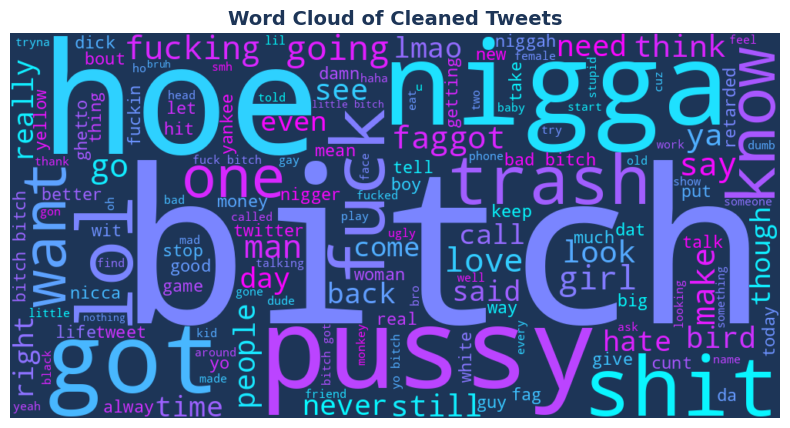

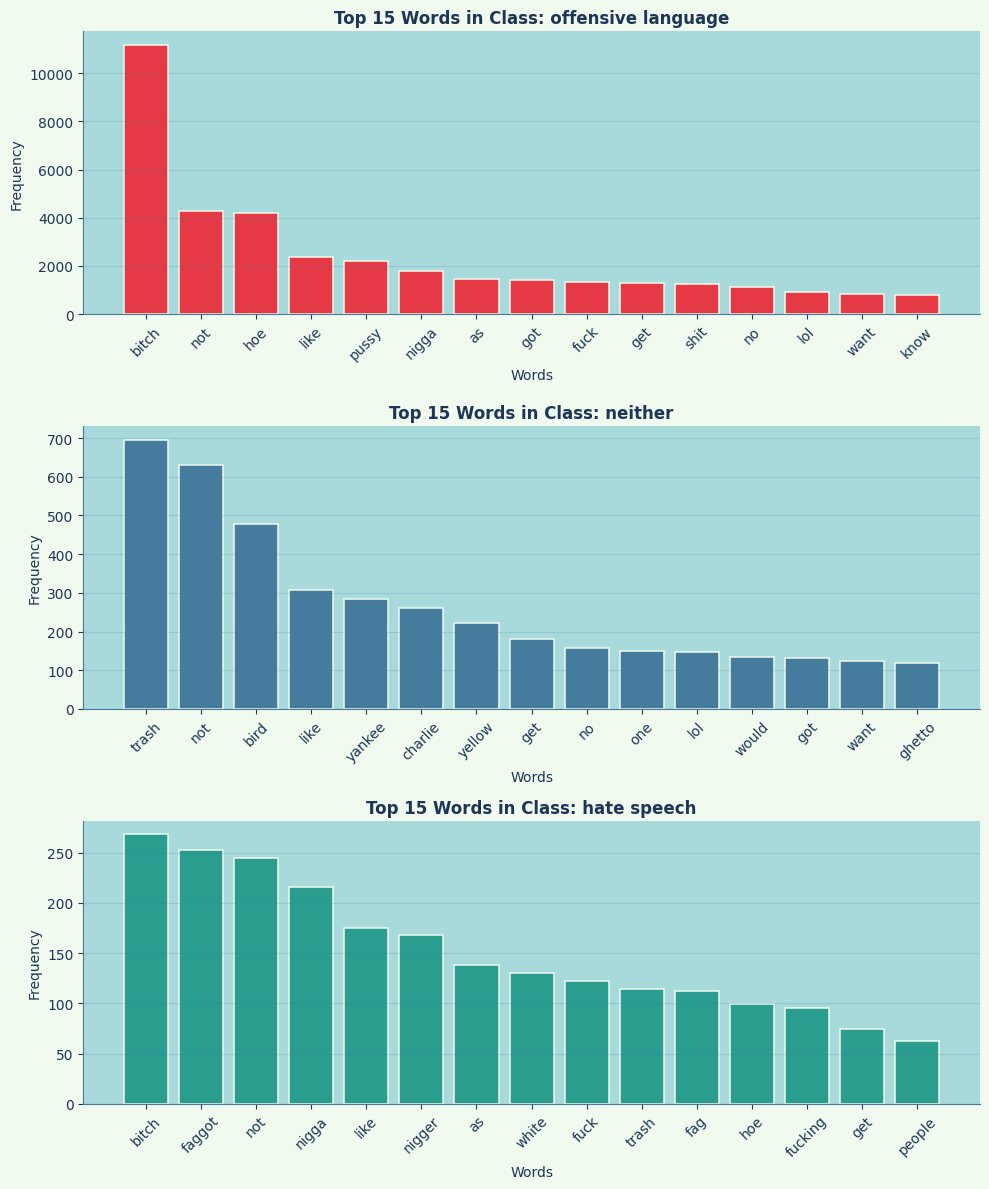

In [32]:
from wordcloud import WordCloud

all_text = " ".join(df["clean_text"])

plt.figure(figsize=(10, 5))
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="#1D3557",
    colormap="cool",
    max_words=150
).generate(all_text)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Tweets", color="#1D3557", fontsize=14, fontweight='bold')
plt.show()

class_names_for_plot = df["label"].value_counts().index.tolist()

BAR_COLORS = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261']

fig, axes = plt.subplots(len(class_names_for_plot), 1, figsize=(10, 4 * len(class_names_for_plot)))
fig.patch.set_facecolor('#F1FAEE')

if len(class_names_for_plot) == 1:
    axes = [axes]

for ax, label, color in zip(axes, class_names_for_plot, BAR_COLORS):
    words = " ".join(df[df["label"] == label]["clean_text"]).split()
    top_words = Counter(words).most_common(15)

    if len(top_words) == 0:
        ax.set_title(f"No words available for {label}")
        continue

    word_labels, word_counts = zip(*top_words)

    ax.set_facecolor('#A8DADC')
    ax.bar(word_labels, word_counts, color=color, edgecolor='#F1FAEE', linewidth=1.1)
    ax.set_title(f"Top 15 Words in Class: {label}", color='#1D3557', fontweight='bold')
    ax.set_xlabel("Words", color='#1D3557')
    ax.set_ylabel("Frequency", color='#1D3557')
    ax.tick_params(axis="x", rotation=45, colors='#1D3557')
    ax.tick_params(axis="y", colors='#1D3557')
    ax.grid(axis='y', alpha=0.2, color='#457B9D')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#457B9D')

plt.tight_layout()
plt.show()

## 8. Label Encoding, 80/20 Split, Tokenisation and Percentile-Based Padding

The dataset is split into 80% training and 20% testing. A separate validation split is then taken from the training set for model monitoring during training.

The maximum sequence length is selected using the 95th percentile of training sequence lengths. This avoids making all sequences extremely long because of a few outlier tweets.

In [33]:
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["label"])

CLASS_NAMES = label_encoder.classes_.tolist()
NUM_CLASSES = len(CLASS_NAMES)

print("Encoded classes:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"{idx}: {name}")

X_clean = df["clean_text"].values
X_raw = df["text"].values
y = df["label_id"].values

X_train_text, X_test_text, X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_clean,
    X_raw,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("\nTrain size:", len(X_train_text))
print("Test size:", len(X_test_text))

VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

train_sequences = tokenizer.texts_to_sequences(X_train_text)
test_sequences = tokenizer.texts_to_sequences(X_test_text)

sequence_lengths = np.array([len(seq) for seq in train_sequences if len(seq) > 0])
MAX_LEN = int(np.percentile(sequence_lengths, 95))
MAX_LEN = max(MAX_LEN, 5)

print("\nActual vocabulary size:", len(tokenizer.word_index) + 1)
print("Vocabulary limit:", VOCAB_SIZE)
print("Maximum sequence length using 95th percentile:", MAX_LEN)

X_train_seq = pad_sequences(
    train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_seq = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_tr_seq, X_val_seq, y_tr, y_val = train_test_split(
    X_train_seq,
    y_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train
)

print("\nTraining tensor shape:", X_tr_seq.shape)
print("Validation tensor shape:", X_val_seq.shape)
print("Test tensor shape:", X_test_seq.shape)

Encoded classes:
0: hate speech
1: neither
2: offensive language

Train size: 19824
Test size: 4957

Actual vocabulary size: 15918
Vocabulary limit: 20000
Maximum sequence length using 95th percentile: 14

Training tensor shape: (16850, 14)
Validation tensor shape: (2974, 14)
Test tensor shape: (4957, 14)


## 9. Class Weights for Class Imbalance

The dataset is imbalanced, so class weights are used during model training. This helps the model pay more attention to minority classes instead of mainly learning the majority class.

In [34]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_tr),
    y=y_tr
)

class_weight_dict = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(y_tr), class_weights_array)
}

print("Class weights:")
for class_id, weight in class_weight_dict.items():
    print(f"{CLASS_NAMES[class_id]}: {weight:.4f}")

Class weights:
hate speech: 5.7785
neither: 1.9847
offensive language: 0.4305


## 10. Model 1: Simple RNN with Trainable Embedding

This is the baseline recurrent model. It learns its own embedding layer during training.

In [35]:
VOCAB_ACTUAL = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)

def build_simple_rnn(vocab_size, max_len, num_classes):
    model = Sequential([
        Input(shape=(max_len,), name="input_layer"),
        Embedding(
            input_dim=vocab_size,
            output_dim=64,
            mask_zero=True,
            name="trainable_embedding"
        ),
        SimpleRNN(64, name="simple_rnn"),
        Dropout(0.4, name="dropout_1"),
        Dense(64, activation="relu", name="dense_1"),
        Dropout(0.3, name="dropout_2"),
        Dense(num_classes, activation="softmax", name="output_layer")
    ], name="Model_1_SimpleRNN")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model1 = build_simple_rnn(VOCAB_ACTUAL, MAX_LEN, NUM_CLASSES)
model1.summary()

Model: "Model_1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ trainable_embedding (Embedding) │ (None, 14, 64)         │     1,018,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,031,363 (3.93 MB)

 Trainable params: 1,031,363 (3.93 MB)

 Non-trainable params: 0 (0.00 B)

## 11. Model 2: LSTM with Trainable Embedding

The LSTM model is designed to capture longer sequential dependencies better than a Simple RNN because it uses gates to control information flow.

In [36]:
def build_lstm(vocab_size, max_len, num_classes):
    model = Sequential([
        Input(shape=(max_len,), name="input_layer"),
        Embedding(
            input_dim=vocab_size,
            output_dim=128,
            mask_zero=True,
            name="trainable_embedding"
        ),
        LSTM(128, name="lstm_layer"),
        Dropout(0.4, name="dropout_1"),
        Dense(64, activation="relu", name="dense_1"),
        Dropout(0.3, name="dropout_2"),
        Dense(num_classes, activation="softmax", name="output_layer")
    ], name="Model_2_LSTM")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model2 = build_lstm(VOCAB_ACTUAL, MAX_LEN, NUM_CLASSES)
model2.summary()

Model: "Model_2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ trainable_embedding (Embedding) │ (None, 14, 128)        │     2,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,177,539 (8.31 MB)

 Trainable params: 2,177,539 (8.31 MB)

 Non-trainable params: 0 (0.00 B)

## 12. Model 3: LSTM with Pretrained GloVe Embeddings

This model uses pretrained GloVe Twitter embeddings loaded through `gensim`. The embedding layer is frozen so that the model uses the pretrained semantic representations directly.

In [37]:
import gensim.downloader as api

print("Loading pretrained GloVe Twitter embeddings...")
embedding_model = api.load("glove-twitter-50")
EMBED_DIM_PRETRAINED = 50
print("Embedding model loaded.")

embedding_matrix = np.zeros((VOCAB_ACTUAL, EMBED_DIM_PRETRAINED))

hits = 0
misses = 0

for word, index in tokenizer.word_index.items():
    if index >= VOCAB_ACTUAL:
        continue

    if word in embedding_model:
        embedding_matrix[index] = embedding_model[word]
        hits += 1
    else:
        misses += 1

coverage = hits / (hits + misses) if (hits + misses) > 0 else 0

print("Words covered by pretrained embeddings:", hits)
print("Words not found in pretrained embeddings:", misses)
print(f"Embedding coverage: {coverage:.2%}")

def build_lstm_pretrained(vocab_size, max_len, num_classes, embedding_matrix):
    model = Sequential([
        Input(shape=(max_len,), name="input_layer"),
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBED_DIM_PRETRAINED,
            weights=[embedding_matrix],
            trainable=False,
            mask_zero=True,
            name="pretrained_glove_embedding"
        ),
        LSTM(128, name="lstm_layer"),
        Dropout(0.4, name="dropout_1"),
        Dense(64, activation="relu", name="dense_1"),
        Dropout(0.3, name="dropout_2"),
        Dense(num_classes, activation="softmax", name="output_layer")
    ], name="Model_3_LSTM_Pretrained_GloVe")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model3 = build_lstm_pretrained(VOCAB_ACTUAL, MAX_LEN, NUM_CLASSES, embedding_matrix)
model3.summary()

Loading pretrained GloVe Twitter embeddings...
Embedding model loaded.
Words covered by pretrained embeddings: 14073
Words not found in pretrained embeddings: 1844
Embedding coverage: 88.41%


Model: "Model_3_LSTM_Pretrained_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_glove_embedding      │ (None, 14, 50)         │       795,900 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 128)            │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 895,999 (3.42 MB)

 Trainable params: 100,099 (391.01 KB)

 Non-trainable params: 795,900 (3.04 MB)

## 13. Train the Models

Early stopping prevents unnecessary training once validation loss stops improving. ReduceLROnPlateau lowers the learning rate when validation performance becomes stagnant.

In [38]:
EPOCHS = 20
BATCH_SIZE = 64

def train_model(model, model_name):
    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

    print(f"\n{'=' * 70}")
    print(f"Training {model_name}")
    print(f"{'=' * 70}")

    start_time = time.time()

    history = model.fit(
        X_tr_seq,
        y_tr,
        validation_data=(X_val_seq, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )

    training_time = time.time() - start_time

    print(f"\nTraining time for {model_name}: {training_time:.2f} seconds")

    return history, training_time

history1, time1 = train_model(model1, "Model 1: Simple RNN")
history2, time2 = train_model(model2, "Model 2: LSTM")
history3, time3 = train_model(model3, "Model 3: LSTM with Pretrained GloVe")


Training Model 1: Simple RNN
Epoch 1/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7147 - loss: 0.8073 - val_accuracy: 0.7946 - val_loss: 0.5902 - learning_rate: 0.0010
Epoch 2/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8468 - loss: 0.3900 - val_accuracy: 0.8030 - val_loss: 0.5192 - learning_rate: 0.0010
Epoch 3/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9110 - loss: 0.2060 - val_accuracy: 0.8342 - val_loss: 0.5060 - learning_rate: 0.0010
Epoch 4/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9448 - loss: 0.1255 - val_accuracy: 0.8225 - val_loss: 0.6093 - learning_rate: 0.0010
Epoch 5/20
261/264 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9512 - loss: 0.1030
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
264/264 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9555 - loss: 0.0980 - val_accuracy: 0.8457 - val_loss: 0.5823 - learning_rate: 0.0010
Epoch 6/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step 

## 14. Training and Validation Curves

The loss and accuracy curves are used to identify overfitting, underfitting, and convergence behaviour.

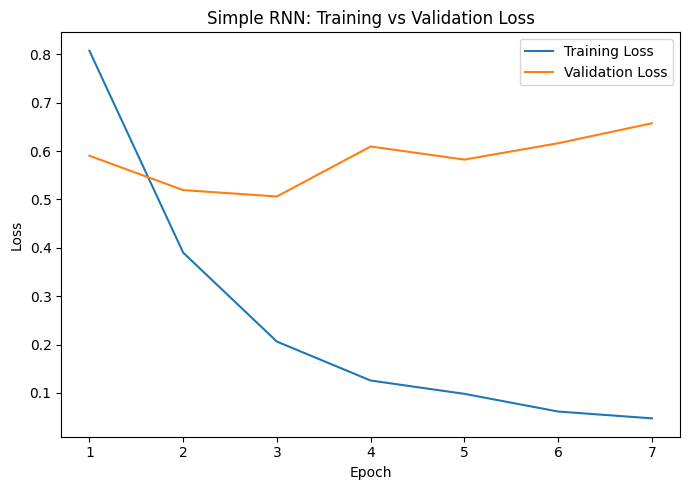

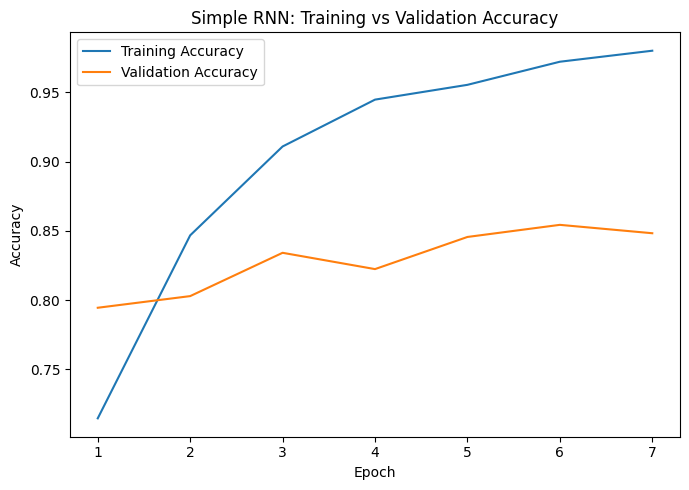

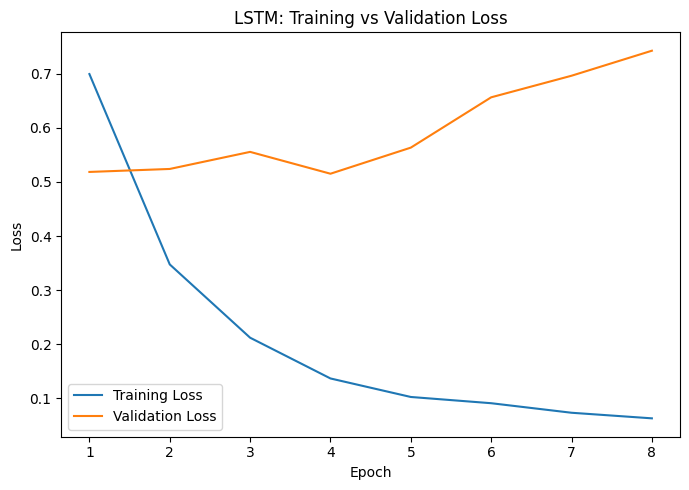

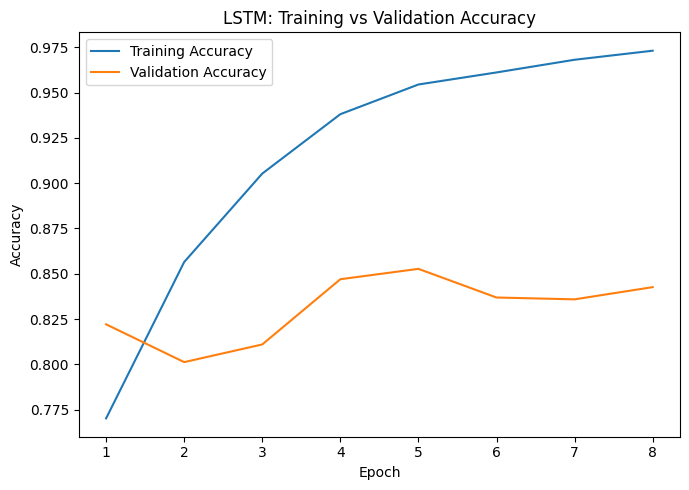

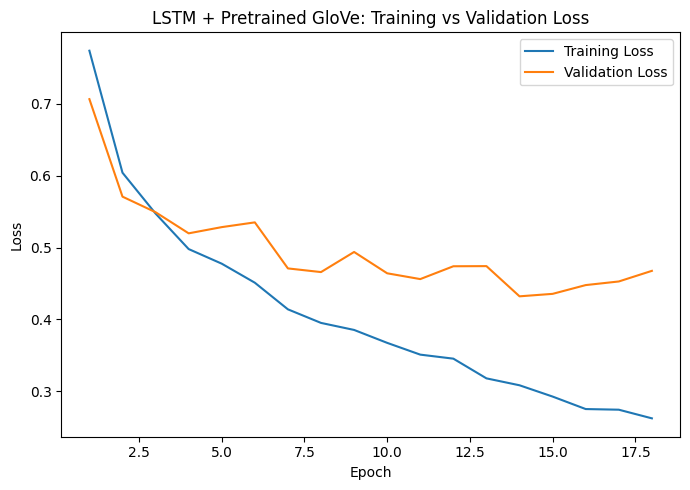

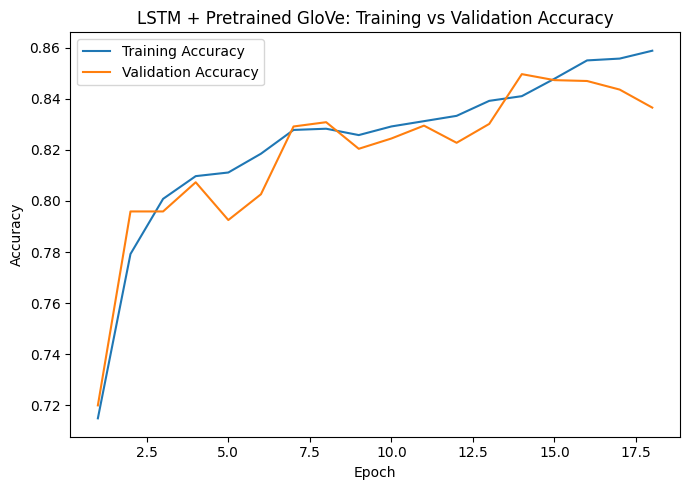

In [39]:
def plot_training_history(history, model_name):
    epochs_range = range(1, len(history.history["loss"]) + 1)

    plt.figure(figsize=(7, 5))
    plt.plot(epochs_range, history.history["loss"], label="Training Loss")
    plt.plot(epochs_range, history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name}: Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(epochs_range, history.history["accuracy"], label="Training Accuracy")
    plt.plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name}: Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_training_history(history1, "Simple RNN")
plot_training_history(history2, "LSTM")
plot_training_history(history3, "LSTM + Pretrained GloVe")

## 15. Model Evaluation

Each model is evaluated using accuracy, confusion matrix, precision, recall, and F1-score. Macro F1-score is especially important because the dataset is imbalanced.


Model 1: Simple RNN - Test Accuracy: 0.8287
                    precision    recall  f1-score   support

       hate speech       0.24      0.49      0.32       286
           neither       0.81      0.82      0.82       833
offensive language       0.93      0.85      0.89      3838

          accuracy                           0.83      4957
         macro avg       0.66      0.72      0.68      4957
      weighted avg       0.87      0.83      0.85      4957



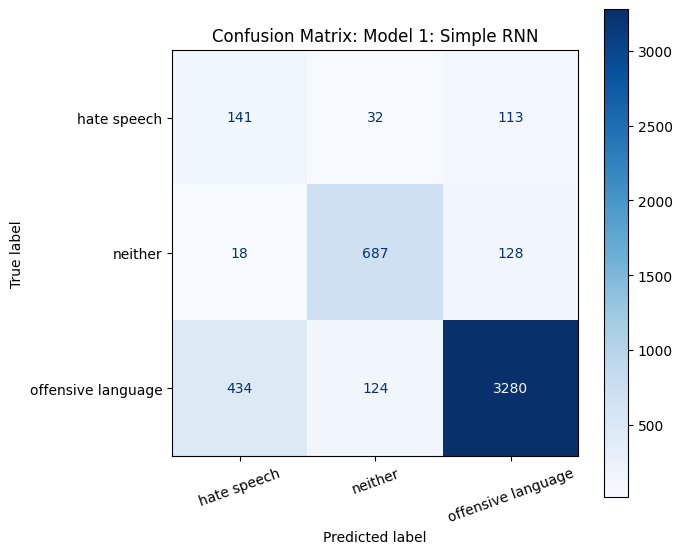


Model 2: LSTM - Test Accuracy: 0.8483
                    precision    recall  f1-score   support

       hate speech       0.26      0.47      0.33       286
           neither       0.81      0.86      0.83       833
offensive language       0.94      0.87      0.91      3838

          accuracy                           0.85      4957
         macro avg       0.67      0.73      0.69      4957
      weighted avg       0.88      0.85      0.86      4957



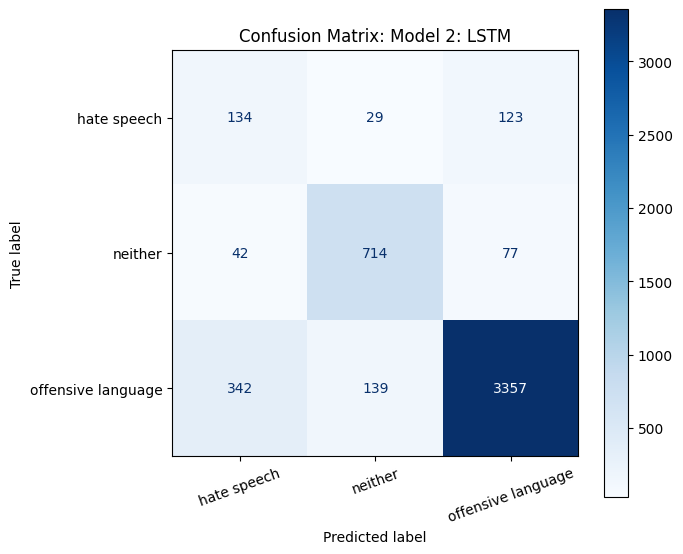


Model 3: LSTM with Pretrained GloVe - Test Accuracy: 0.8511
                    precision    recall  f1-score   support

       hate speech       0.30      0.63      0.40       286
           neither       0.78      0.93      0.85       833
offensive language       0.97      0.85      0.91      3838

          accuracy                           0.85      4957
         macro avg       0.68      0.80      0.72      4957
      weighted avg       0.90      0.85      0.87      4957



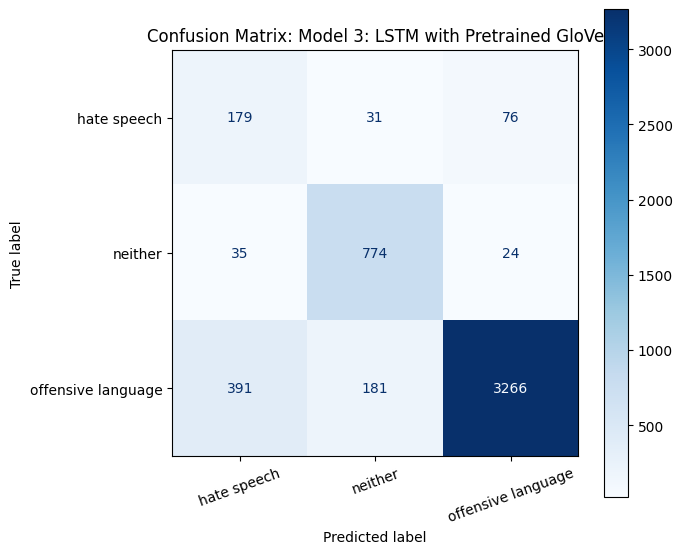

In [40]:
def evaluate_model(model, model_name):
    probabilities = model.predict(X_test_seq, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    accuracy = accuracy_score(y_test, predictions)

    print(f"\n{'=' * 70}")
    print(f"{model_name} - Test Accuracy: {accuracy:.4f}")
    print(f"{'=' * 70}")

    report_text = classification_report(
        y_test,
        predictions,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES,
        zero_division=0
    )

    print(report_text)

    report_dict = classification_report(
        y_test,
        predictions,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES,
        zero_division=0,
        output_dict=True
    )

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=np.arange(NUM_CLASSES)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap="Blues", values_format="d", ax=ax)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": accuracy,
        "report": report_dict,
        "predictions": predictions,
        "probabilities": probabilities,
        "confusion_matrix": cm
    }

eval1 = evaluate_model(model1, "Model 1: Simple RNN")
eval2 = evaluate_model(model2, "Model 2: LSTM")
eval3 = evaluate_model(model3, "Model 3: LSTM with Pretrained GloVe")

## 16. Model Comparison Table

The best model is selected using Macro F1-score, not accuracy alone. This is more appropriate for imbalanced classification because it gives equal importance to all classes.

In [41]:
minority_label = df["label"].value_counts().idxmin()

comparison_results = []

model_info = [
    ("Simple RNN", model1, eval1, time1, history1),
    ("LSTM", model2, eval2, time2, history2),
    ("LSTM + Pretrained GloVe", model3, eval3, time3, history3)
]

for model_name, model, evaluation, train_time, history in model_info:
    report = evaluation["report"]

    comparison_results.append({
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"],
        f"{minority_label} Recall": report[minority_label]["recall"],
        "Training Time (s)": train_time,
        "Epochs Trained": len(history.history["loss"]),
        "Parameters": model.count_params()
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values(by="Macro F1", ascending=False).reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.loc[0, "Model"]
print("Best model based on Macro F1:", best_model_name)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,hate speech Recall,Training Time (s),Epochs Trained,Parameters
0,LSTM + Pretrained GloVe,0.851120,0.683716,0.802003,0.719844,0.868226,0.625874,209.969923,18,895999
1,LSTM,0.848295,0.670661,0.733450,0.691299,0.862113,0.468531,138.299641,8,2177539
2,Simple RNN,0.828727,0.661425,0.724116,0.677351,0.846469,0.493007,48.368045,7,1031363


Best model based on Macro F1: LSTM + Pretrained GloVe


## 17. Model Comparison Visualisation

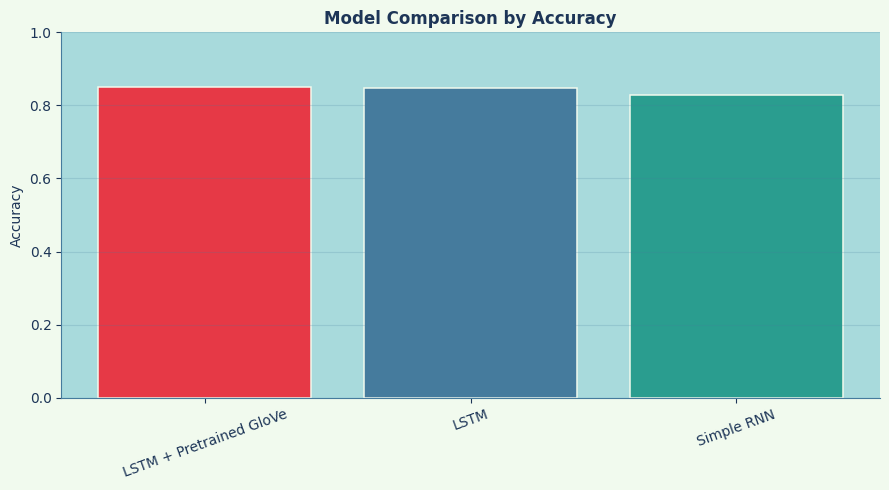

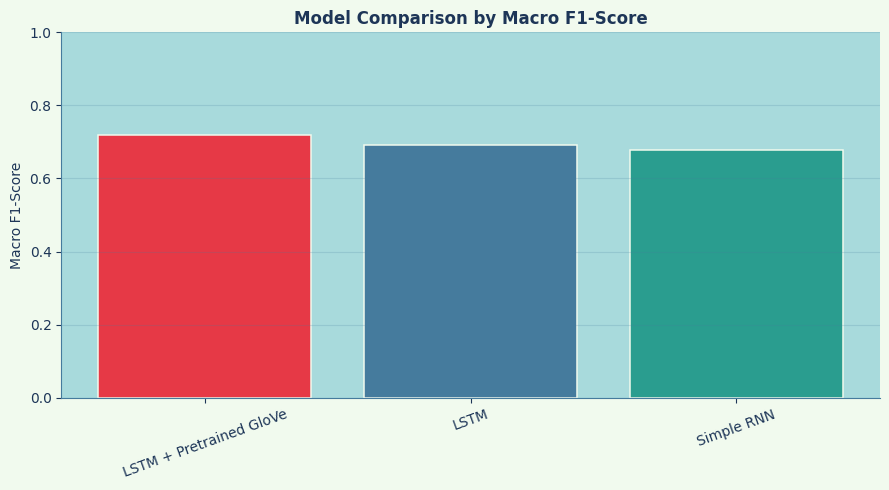

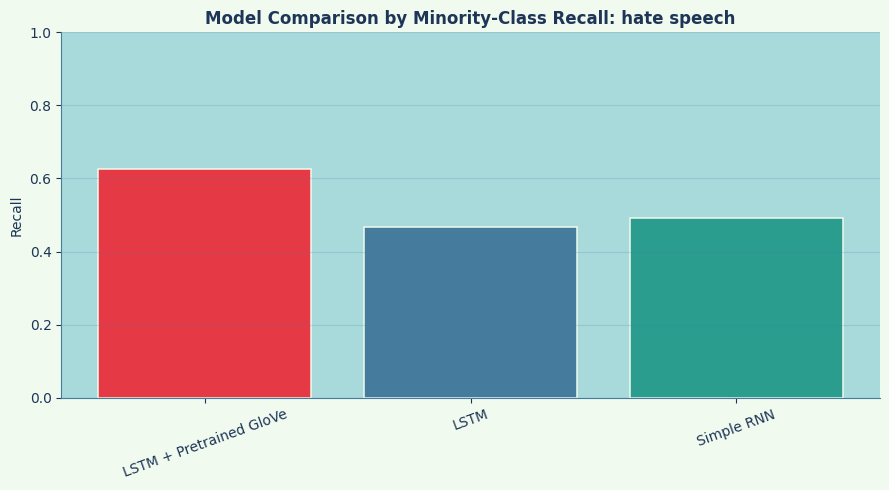

In [42]:
BAR_COLORS = ['#E63946', '#457B9D', '#2A9D8F']
BG_COLOR   = '#F1FAEE'
AXES_COLOR = '#A8DADC'
TEXT_COLOR = '#1D3557'
GRID_COLOR = '#457B9D'

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(AXES_COLOR)
ax.bar(comparison_df["Model"], comparison_df["Accuracy"],
       color=BAR_COLORS, edgecolor='#F1FAEE', linewidth=1.1)
ax.set_title("Model Comparison by Accuracy", color=TEXT_COLOR, fontweight='bold')
ax.set_ylabel("Accuracy", color=TEXT_COLOR)
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=20, colors=TEXT_COLOR)
ax.tick_params(axis='y', colors=TEXT_COLOR)
ax.grid(axis='y', alpha=0.2, color=GRID_COLOR)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(GRID_COLOR)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(AXES_COLOR)
ax.bar(comparison_df["Model"], comparison_df["Macro F1"],
       color=BAR_COLORS, edgecolor='#F1FAEE', linewidth=1.1)
ax.set_title("Model Comparison by Macro F1-Score", color=TEXT_COLOR, fontweight='bold')
ax.set_ylabel("Macro F1-Score", color=TEXT_COLOR)
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=20, colors=TEXT_COLOR)
ax.tick_params(axis='y', colors=TEXT_COLOR)
ax.grid(axis='y', alpha=0.2, color=GRID_COLOR)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(GRID_COLOR)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(AXES_COLOR)
ax.bar(comparison_df["Model"], comparison_df[f"{minority_label} Recall"],
       color=BAR_COLORS, edgecolor='#F1FAEE', linewidth=1.1)
ax.set_title(f"Model Comparison by Minority-Class Recall: {minority_label}", color=TEXT_COLOR, fontweight='bold')
ax.set_ylabel("Recall", color=TEXT_COLOR)
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=20, colors=TEXT_COLOR)
ax.tick_params(axis='y', colors=TEXT_COLOR)
ax.grid(axis='y', alpha=0.2, color=GRID_COLOR)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(GRID_COLOR)
plt.tight_layout()
plt.show()

## 18. Model Comparison Discussion

The models were compared using accuracy, macro F1-score, weighted F1-score, training time, and minority-class recall. Accuracy alone is not sufficient for this dataset because the class distribution is imbalanced. A model can achieve high accuracy by mainly predicting the majority class while still failing to detect hate speech examples.

The Simple RNN provides a useful baseline because it processes text sequentially, but it has limited ability to capture longer dependencies. The LSTM model is expected to perform better because its gating mechanism helps retain useful contextual information and reduces the vanishing-gradient problem. The pretrained GloVe embedding model uses word representations learned from a larger external corpus, which can improve generalisation, especially when some words appear rarely in the training data.

For final model selection, macro F1-score is treated as more important than accuracy because it gives equal importance to each class. Minority-class recall is also important because missing hate speech examples is more harmful than simply achieving high overall accuracy.

## 19. Select the Best Model

In [43]:
model_lookup = {
    "Simple RNN": model1,
    "LSTM": model2,
    "LSTM + Pretrained GloVe": model3
}

eval_lookup = {
    "Simple RNN": eval1,
    "LSTM": eval2,
    "LSTM + Pretrained GloVe": eval3
}

best_model = model_lookup[best_model_name]
best_eval = eval_lookup[best_model_name]

print("Selected best model:", best_model_name)

Selected best model: LSTM + Pretrained GloVe


## 20. Error Analysis

This section displays misclassified examples and supports interpretation of why the model made mistakes.

In [44]:
def error_analysis(evaluation, model_name, n=5):
    predictions = evaluation["predictions"]
    probabilities = evaluation["probabilities"]

    error_indices = np.where(predictions != y_test)[0]

    print(f"Total test examples: {len(y_test)}")
    print(f"Misclassified examples by {model_name}: {len(error_indices)}")

    rows = []

    for idx in error_indices[:n]:
        true_label = CLASS_NAMES[y_test[idx]]
        predicted_label = CLASS_NAMES[predictions[idx]]
        confidence = probabilities[idx][predictions[idx]]

        rows.append({
            "Raw Text": X_test_raw[idx],
            "Cleaned Text": X_test_text[idx],
            "True Label": true_label,
            "Predicted Label": predicted_label,
            "Prediction Confidence": round(float(confidence), 4)
        })

    error_df = pd.DataFrame(rows)
    display(error_df)

    return error_df

error_df = error_analysis(best_eval, best_model_name, n=5)

Total test examples: 4957
Misclassified examples by LSTM + Pretrained GloVe: 738


,Raw Text,Cleaned Text,True Label,Predicted Label,Prediction Confidence
0,"@Woody_AFC lmaoo typical nig nog bombs, should...",lmaoo typical nig nog bomb got pic,offensive language,neither,0.7542
1,@GrizzboAdams ight nigga tonight at 9:00 c bur...,ight nigga tonight burg mall bitch,offensive language,hate speech,0.5391
2,RT @SariyaDaniellee: &#8220;@JayJuice22: The n...,nigga got slept faggot sue run one watch ya ba...,offensive language,hate speech,0.7778
3,&#8220;@jooselhynn_: U hella gay u never did&#...,hella gay never quit subbing fag,offensive language,hate speech,0.6529
4,@theBOSS_Leslie I didn't tag you negro lol,not tag negro lol,offensive language,neither,0.7767


## 21. Error Analysis Discussion

The misclassified examples show that the model often struggles when the boundary between offensive language and hate speech is unclear. This is expected because both classes may contain insults, profanity, or aggressive expressions. However, hate speech usually depends on whether the attack is targeted toward a protected group, which may require deeper contextual understanding than a standard RNN or LSTM can provide.

Some errors may also occur because preprocessing removes punctuation, user mentions, and formatting cues that could carry pragmatic meaning. In addition, the dataset is imbalanced, so the model receives fewer hate speech examples during training. This makes minority-class recall harder to optimise.

Possible improvements include stronger class-balancing methods such as oversampling, focal loss, or more advanced contextual language models such as BERT. Hyperparameter tuning, larger datasets, and manual inspection of ambiguous labels could also improve performance.

## 22. Save the Best Model and Supporting Files

This step makes the work reproducible and allows the trained model to be reused.

In [45]:
output_dir = Path("/content/part3_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

best_model.save(output_dir / "best_text_classification_model.keras")

with open(output_dir / "tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open(output_dir / "label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

comparison_df.to_csv(output_dir / "model_comparison_results.csv", index=False)

print("Saved files:")
for file in output_dir.iterdir():
    print(file)

Saved files:
/content/part3_outputs/tokenizer.pkl
/content/part3_outputs/best_text_classification_model.keras
/content/part3_outputs/label_encoder.pkl
/content/part3_outputs/model_comparison_results.csv


## 23. Real-Time Prediction Function

In [46]:
def predict_text_label(text):
    cleaned = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    probabilities = best_model.predict(padded, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_label = CLASS_NAMES[predicted_index]
    confidence = float(probabilities[predicted_index])

    result = {
        "cleaned_text": cleaned,
        "predicted_label": predicted_label,
        "confidence": confidence,
        "class_probabilities": {
            CLASS_NAMES[i]: float(probabilities[i])
            for i in range(NUM_CLASSES)
        }
    }

    return result

sample_text = "I cannot believe how stupid this comment is"
predict_text_label(sample_text)

{'cleaned_text': 'cannot believe stupid comment',
 'predicted_label': 'neither',
 'confidence': 0.5116651058197021,
 'class_probabilities': {'hate speech': 0.28323328495025635,
  'neither': 0.5116651058197021,
  'offensive language': 0.20510153472423553}}

## 24. Gradio GUI for Real-Time Prediction

This interface allows a user to enter a tweet and receive predicted class probabilities in real time.

In [47]:
import gradio as gr

def gradio_predict(tweet):
    cleaned = clean_text(tweet)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    probabilities = best_model.predict(padded, verbose=0)[0]

    return {
        CLASS_NAMES[i]: float(probabilities[i])
        for i in range(NUM_CLASSES)
    }

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter a tweet here...",
        label="Input Tweet"
    ),
    outputs=gr.Label(
        num_top_classes=NUM_CLASSES,
        label="Predicted Class Probabilities"
    ),
    title="Hate Speech and Offensive Language Classifier",
    description=(
        "This interface uses the best-performing model selected by Macro F1-score "
        "to classify a tweet as hate speech, offensive language, or neither."
    ),
    examples=[
        ["I hope everyone has a great day."],
        ["This is the worst thing I have ever seen."],
        ["Those people should not be allowed here."]
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e90e145b72a3034c5c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 25. Final Conclusion

This notebook implemented three recurrent neural network models for hate speech and offensive language classification. The pipeline included text cleaning, tokenisation, percentile-based padding, class weighting for imbalance, model training, evaluation, comparison, error analysis, and a real-time Gradio interface.

The final model should be selected using macro F1-score rather than accuracy alone because the dataset is imbalanced. The results should be interpreted carefully, especially for the minority hate speech class, where recall is critical. Future improvements could include focal loss, oversampling, more advanced transformer-based models such as BERT, and manual review of ambiguous labels.